In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [4]:
df = pd.read_csv("/content/sonakshi_customer_purchase_prediction.csv")
print(df.shape)
df.head()

(2000, 8)


,visits_last_month,avg_time_spent_min,discount_offered,loyalty_points,age,income_level,previous_purchases,will_purchase
0,14.0,24.4,6.0,2522.0,43.0,10.0,20.0,1
1,7.0,24.1,27.0,4548.0,45.0,4.0,21.0,0
2,175.0,29.2,2.0,3510.0,50.0,10.0,91.0,1
3,18.0,13.0,50.0,2558.0,54.0,9.0,74.0,1
4,23.0,5.3,49.0,3163.0,59.0,1.0,49.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visits_last_month   1953 non-null   float64
 1   avg_time_spent_min  1949 non-null   float64
 2   discount_offered    1945 non-null   float64
 3   loyalty_points      1952 non-null   float64
 4   age                 1950 non-null   float64
 5   income_level        1954 non-null   float64
 6   previous_purchases  1955 non-null   float64
 7   will_purchase       2000 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 125.1 KB


In [6]:
df.describe()

,visits_last_month,avg_time_spent_min,discount_offered,loyalty_points,age,income_level,previous_purchases,will_purchase
count,1953.000000,1949.000000,1945.000000,1952.000000,1950.000000,1954.000000,1955.000000,2000.000000
mean,6.823861,21.363263,18.265296,2514.799180,34.607692,-4.612590,38.923274,0.503500
std,95.380895,106.725631,88.763908,2066.131926,97.624365,101.215864,119.152931,0.500113
min,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,0.000000
25%,7.000000,16.400000,11.000000,1163.000000,29.000000,3.000000,24.000000,0.000000
50%,15.000000,31.000000,25.000000,2428.000000,41.000000,5.000000,49.000000,1.000000
75%,23.000000,45.700000,38.000000,3737.750000,54.000000,8.000000,76.000000,1.000000
max,210.000000,387.100000,294.000000,34727.000000,455.000000,63.000000,616.000000,1.000000


In [7]:
numeric_cols = ["visits_last_month", "avg_time_spent_min", "discount_offered",
                 "loyalty_points", "age", "income_level", "previous_purchases"]

df[numeric_cols] = df[numeric_cols].replace(-999, np.nan)

In [8]:
df.loc[(df['age'] < 18) | (df['age'] > 90), 'age'] = np.nan
df.loc[(df['income_level'] < 1) | (df['income_level'] > 10), 'income_level'] = np.nan

def cap_extreme_outliers_to_nan(series, k=3):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return series.where((series >= lower) & (series <= upper), np.nan), lower, upper

for col in ['previous_purchases', 'loyalty_points', 'visits_last_month',
            'avg_time_spent_min', 'discount_offered']:
    df[col], lo, hi = cap_extreme_outliers_to_nan(df[col], k=3)

In [9]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [10]:
df = df.drop_duplicates().reset_index(drop=True)

In [11]:
df.describe()

,visits_last_month,avg_time_spent_min,discount_offered,loyalty_points,age,income_level,previous_purchases,will_purchase
count,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000,1995.000000
mean,14.806015,30.870877,24.911779,2477.973935,41.382456,5.490727,50.137845,0.503258
std,8.779876,16.430292,14.743791,1424.714459,13.538962,2.795664,29.597899,0.500115
min,0.000000,1.100000,0.000000,1.000000,18.000000,1.000000,0.000000,0.000000
25%,7.000000,17.400000,12.000000,1242.500000,30.000000,3.000000,25.000000,0.000000
50%,15.000000,31.200000,25.000000,2454.000000,41.000000,5.000000,49.000000,1.000000
75%,22.000000,45.100000,37.000000,3697.000000,53.000000,8.000000,75.500000,1.000000
max,42.000000,61.600000,91.000000,6055.000000,65.000000,10.000000,231.000000,1.000000


/tmp/ipykernel_1909/451799803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='will_purchase', data=df, palette='Set2')


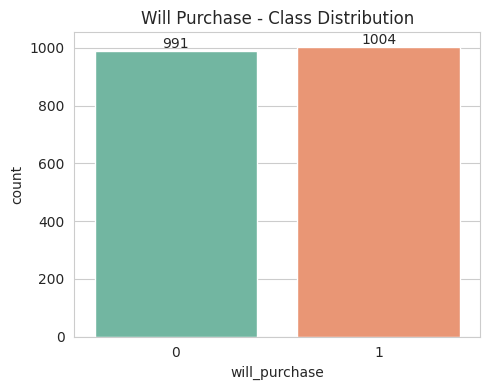

In [12]:

plt.figure(figsize=(5, 4))
ax = sns.countplot(x='will_purchase', data=df, palette='Set2')
ax.set_title('Will Purchase - Class Distribution')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

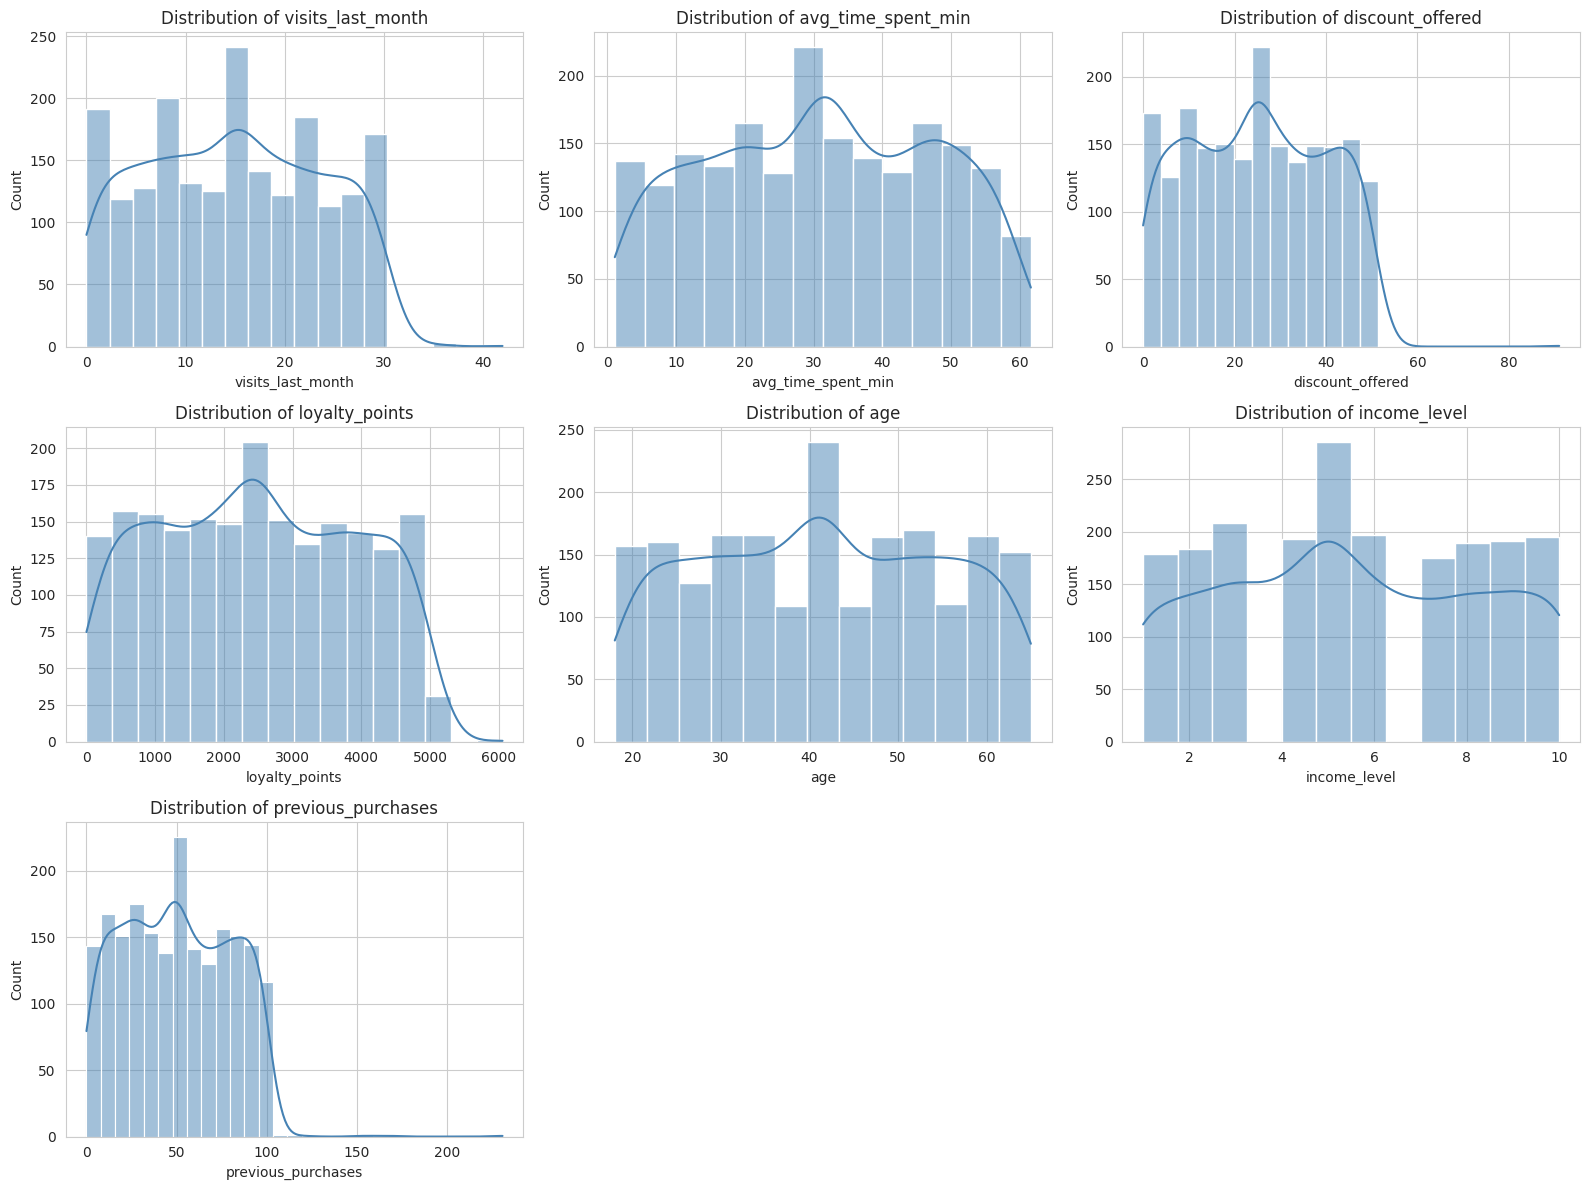

In [13]:

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

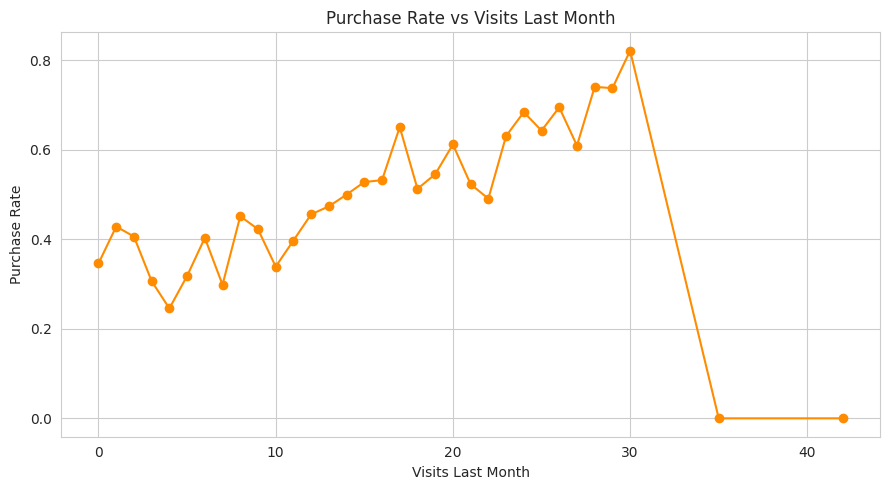

In [14]:

monthly_trend = df.groupby('visits_last_month')['will_purchase'].mean().sort_index()

plt.figure(figsize=(9, 5))
plt.plot(monthly_trend.index, monthly_trend.values, marker='o', color='darkorange')
plt.title('Purchase Rate vs Visits Last Month')
plt.xlabel('Visits Last Month')
plt.ylabel('Purchase Rate')
plt.tight_layout()
plt.show()

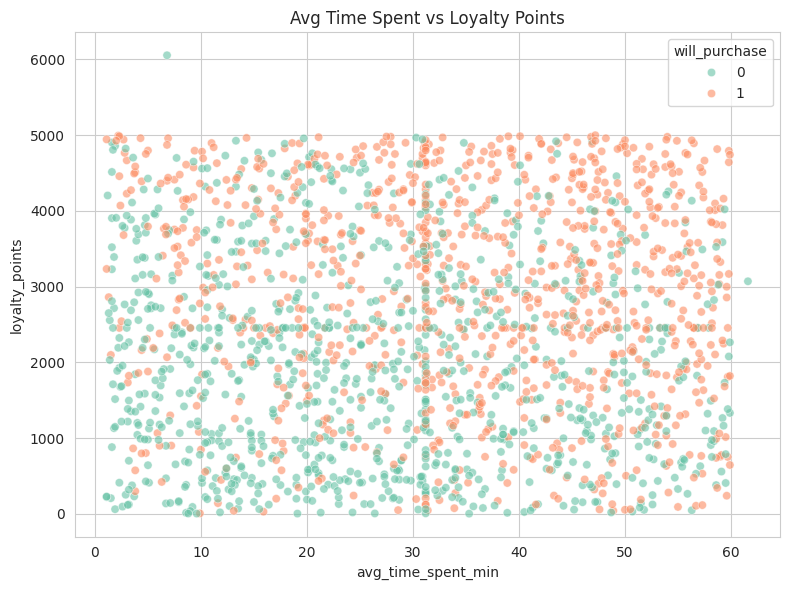

In [15]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x='avg_time_spent_min', y='loyalty_points', hue='will_purchase',
                 data=df, palette='Set2', alpha=0.6)
plt.title('Avg Time Spent vs Loyalty Points')
plt.tight_layout()
plt.show()

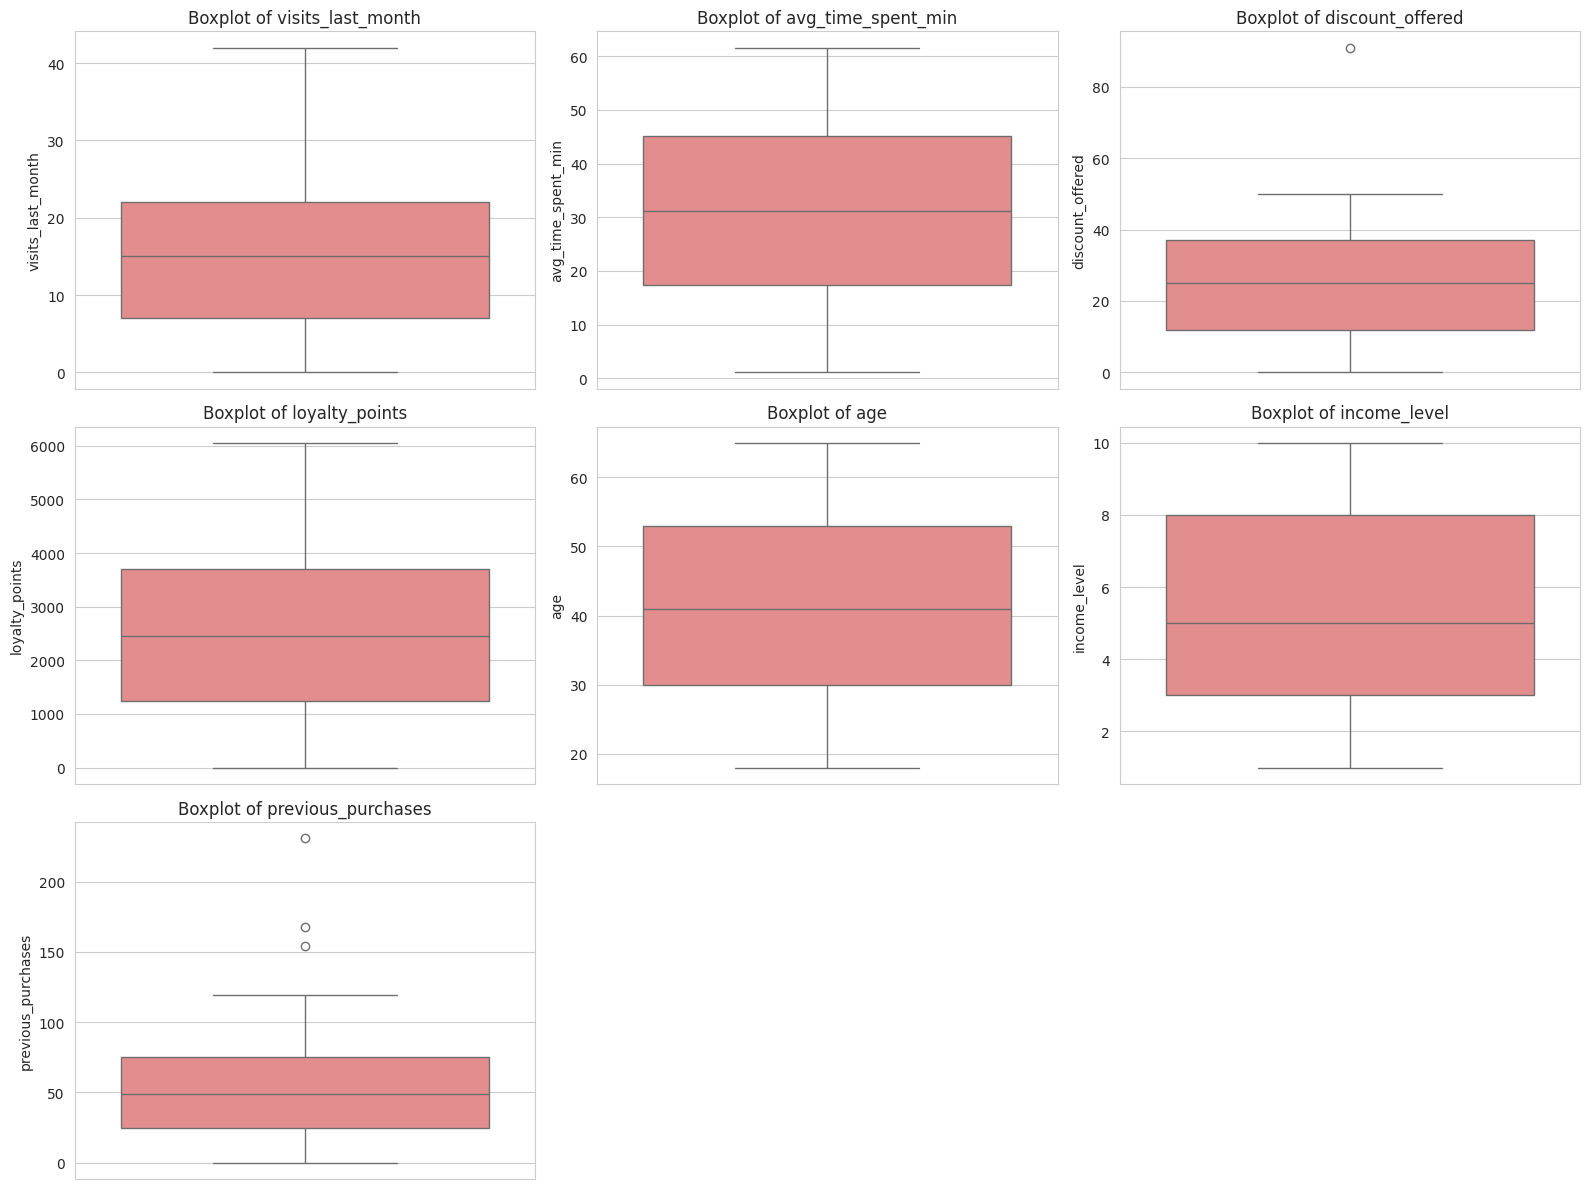

In [16]:

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot of {col}')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

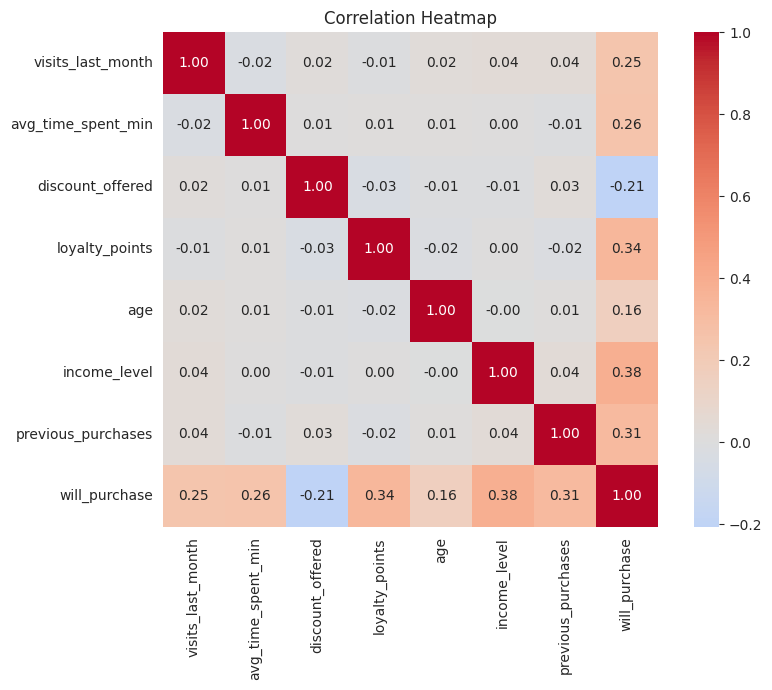

In [17]:

plt.figure(figsize=(9, 7))
corr = df[numeric_cols + ['will_purchase']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [18]:

X = df[numeric_cols]
y = df['will_purchase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

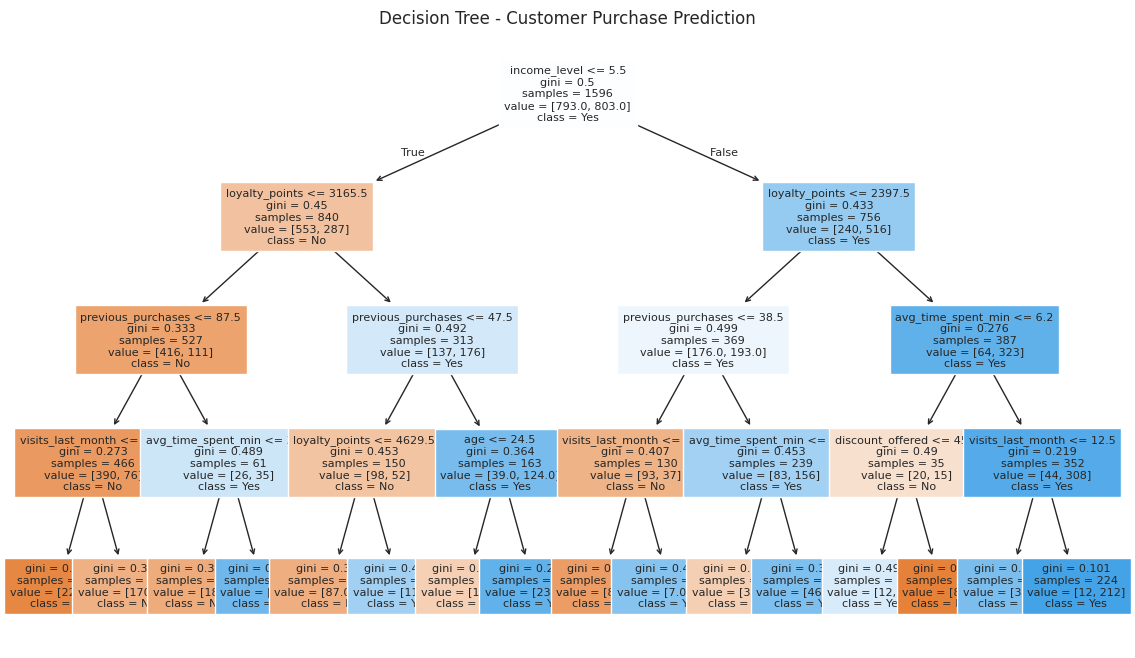

In [19]:
plt.figure(figsize=(14, 8))
plot_tree(model, feature_names=X.columns, class_names=["No", "Yes"], filled=True, fontsize=8)
plt.title("Decision Tree - Customer Purchase Prediction")
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", acc)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No", "Yes"]
))

Test Accuracy: 0.8771929824561403

Confusion Matrix:
[[172  26]
 [ 23 178]]

Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.87      0.88       198
         Yes       0.87      0.89      0.88       201

    accuracy                           0.88       399
   macro avg       0.88      0.88      0.88       399
weighted avg       0.88      0.88      0.88       399



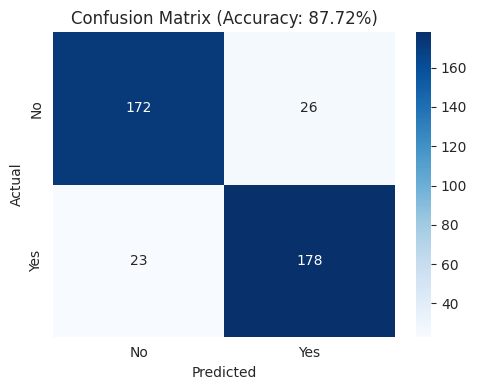

In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title(f"Confusion Matrix (Accuracy: {acc:.2%})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()